### Гипотеза 2: Замена StepLR на CosineAnnealingLR улучшит качество модели за счёт более плавного изменения learning rate.

Импорт библиотек и загрузка результатов экспериментов для сравнения гипотез.

In [ ]:
from common import *
all_results = load_results()

Загрузка параметров обучения и подготовка датасетов с загрузчиками

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка сплитов и подготовки параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
SEED = cfg["seed"] # seed для воспроизводимости
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы изображений для тренировочного набора
val_indices = cfg["val_indices"] # индексы изображений для валидационного набора

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # получение изображений для тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # получение изображений для валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Функция обучения с CosineAnnealing

In [ ]:
def train_model_cosine(model, model_name, train_loader, val_loader, test_loader, epochs=10, lr=1e-3, device=DEVICE):
    """Обучение модели с использованием CosineAnnealingLR"""
    set_seed(SEED)
    model = model.to(device) # перенос модели на устройство
    criterion = nn.CrossEntropyLoss() # функция потерь
    optimizer = optim.Adam(model.parameters(), lr=lr) # оптимизатор
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # scheduler

    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None # масштабирование градиентов

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # история обучения

    for epoch in range(epochs): # проход по всем эпохам
        model.train() # перевод модели в режим обучения
        running_loss = 0.0 # счётчик потерь
        all_preds = [] # список предсказаний
        all_labels = [] # список меток

        for images, labels in train_loader: # обучение на тренировочном наборе
            images, labels = images.to(device), labels.to(device) # перенос данных на устройство
            optimizer.zero_grad() # обнуление градиентов

            if scaler: # если масштабирование градиентов
                with torch.amp.autocast('cuda'): # автомасштабирование градиентов
                    outputs = model(images) # предсказание модели
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.step(optimizer) # обновление параметров
                scaler.update() # обновление масштаба
            else: # если нет масштабирования градиентов
                outputs = model(images) # предсказание модели
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратная прогонка
                optimizer.step() # обновление параметров
            
            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        
        train_loss = running_loss / len(train_loader.dataset) # вычисление среднего потерь
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности

        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка модели на валидационном наборе
        scheduler.step() # обновление scheduler'а

        history["train_loss"].append(train_loss) # добавление потерь в историю
        history["val_loss"].append(val_loss) # добавление потерь в историю
        history["train_acc"].append(train_acc) # добавление точности в историю
        history["val_acc"].append(val_acc) # добавление точности в историю

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    ) # оценка модели на тестовом наборе

    # вывод результатов
    print(f"\n{model_name} -  TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # матрица ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # графики потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # отчёт о классификации
    print(f"{model_name} - Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение результатов
    return {
        "model": model_name,
        "test_acc": test_acc,
        "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1,
        "history": history,
        "confusion_matrix": cm.tolist(),
    }

Обучение модели ResNet18 с CosineAnnealingLR и сохранение результатов

Epoch 1/10 - Train Loss: 0.2825, Train Acc: 0.8898, Val Loss: 0.1631, Val Acc: 0.9458, Val Bal Acc: 0.9459, Val F1: 0.9459
Epoch 2/10 - Train Loss: 0.1024, Train Acc: 0.9647, Val Loss: 0.0519, Val Acc: 0.9809, Val Bal Acc: 0.9810, Val F1: 0.9809
Epoch 3/10 - Train Loss: 0.0462, Train Acc: 0.9851, Val Loss: 0.1196, Val Acc: 0.9538, Val Bal Acc: 0.9539, Val F1: 0.9543
Epoch 4/10 - Train Loss: 0.0277, Train Acc: 0.9905, Val Loss: 0.3834, Val Acc: 0.8800, Val Bal Acc: 0.8803, Val F1: 0.8799
Epoch 5/10 - Train Loss: 0.0206, Train Acc: 0.9936, Val Loss: 0.0157, Val Acc: 0.9940, Val Bal Acc: 0.9940, Val F1: 0.9940
Epoch 6/10 - Train Loss: 0.0063, Train Acc: 0.9982, Val Loss: 0.0092, Val Acc: 0.9965, Val Bal Acc: 0.9965, Val F1: 0.9965
Epoch 7/10 - Train Loss: 0.0013, Train Acc: 0.9996, Val Loss: 0.0074, Val Acc: 0.9975, Val Bal Acc: 0.9975, Val F1: 0.9975
Epoch 8/10 - Train Loss: 0.0024, Train Acc: 0.9994, Val Loss: 0.0117, Val Acc: 0.9975, Val Bal Acc: 0.9975, Val F1: 0.9975
Epoch 9/10 - Tra

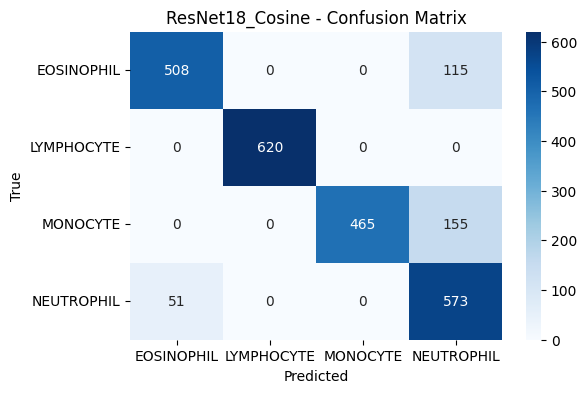

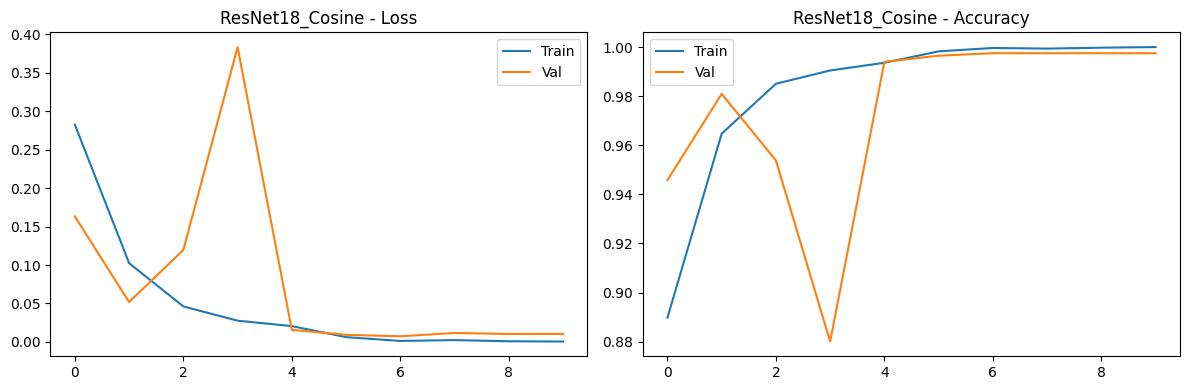

ResNet18_Cosine - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.91      0.82      0.86       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.68      0.92      0.78       624

    accuracy                           0.87      2487
   macro avg       0.90      0.87      0.87      2487
weighted avg       0.90      0.87      0.87      2487

Resnet18 с CosineAnnealingLR обучена и сохранена.


In [ ]:
resnet18_cosine = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # создание модели ResNet18
resnet18_cosine.fc = nn.Linear(resnet18_cosine.fc.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

# обучение модели
resnet18_cosine_results = train_model_cosine(
    resnet18_cosine,
    "ResNet18_Cosine",
    train_loader,
    val_loader,
    test_loader,
    epochs=10,
    lr=1e-3
)

torch.save(resnet18_cosine.state_dict(), "outputs/resnet18_cosine.pth") # сохранение модели
print("Resnet18 с CosineAnnealingLR обучена и сохранена.")

Замена StepLR на CosineAnnealingLR улучшила результат: Accuracy 0.8709 против baseline 0.8544 (+1.65%). Плавное убывание learning rate по косинусному расписанию позволяет модели тоньше настраиваться в поздних эпохах, избегая резких скачков потерь. Отмечен характерный всплеск val loss на эпохе 4 — вероятно, артефакт StepLR-подобного поведения в начале обучения, после которого модель восстановилась.

Обучение модели Swin-T с CosineAnnealingLR и сохранение результатов

Epoch 1/10 - Train Loss: 0.4910, Train Acc: 0.7995, Val Loss: 0.0719, Val Acc: 0.9704, Val Bal Acc: 0.9705, Val F1: 0.9704
Epoch 2/10 - Train Loss: 0.1048, Train Acc: 0.9632, Val Loss: 0.2078, Val Acc: 0.9202, Val Bal Acc: 0.9205, Val F1: 0.9182
Epoch 3/10 - Train Loss: 0.0572, Train Acc: 0.9827, Val Loss: 0.0320, Val Acc: 0.9905, Val Bal Acc: 0.9905, Val F1: 0.9905
Epoch 4/10 - Train Loss: 0.0284, Train Acc: 0.9911, Val Loss: 0.0172, Val Acc: 0.9955, Val Bal Acc: 0.9955, Val F1: 0.9955
Epoch 5/10 - Train Loss: 0.0240, Train Acc: 0.9938, Val Loss: 0.0151, Val Acc: 0.9965, Val Bal Acc: 0.9965, Val F1: 0.9965
Epoch 6/10 - Train Loss: 0.0185, Train Acc: 0.9954, Val Loss: 0.0223, Val Acc: 0.9950, Val Bal Acc: 0.9950, Val F1: 0.9950
Epoch 7/10 - Train Loss: 0.0146, Train Acc: 0.9962, Val Loss: 0.0206, Val Acc: 0.9950, Val Bal Acc: 0.9950, Val F1: 0.9950
Epoch 8/10 - Train Loss: 0.0115, Train Acc: 0.9976, Val Loss: 0.0145, Val Acc: 0.9965, Val Bal Acc: 0.9965, Val F1: 0.9965
Epoch 9/10 - Tra

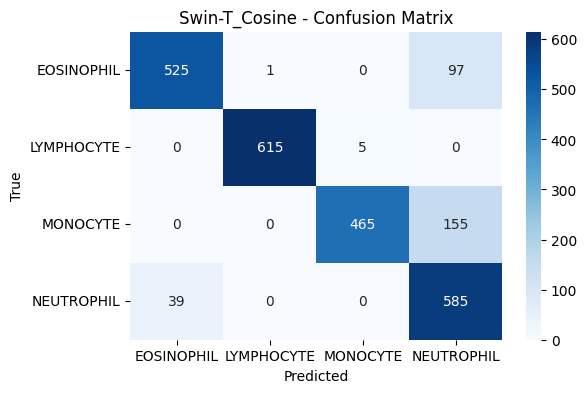

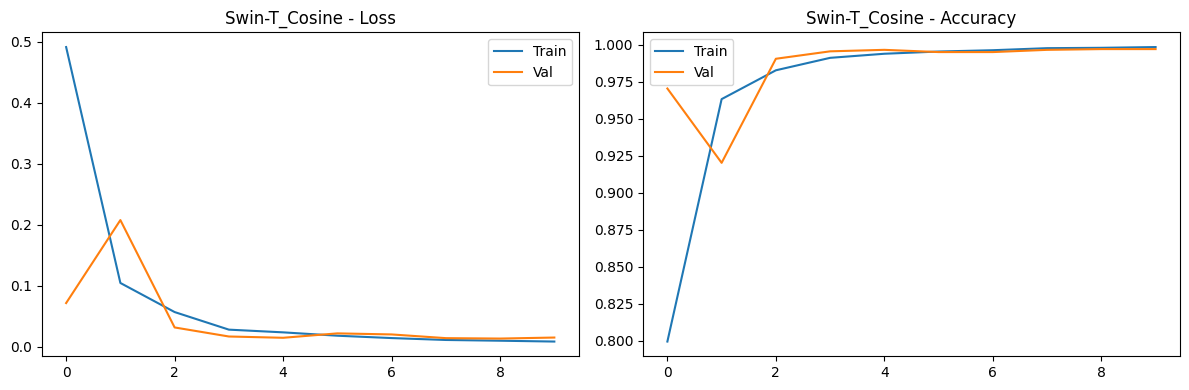

Swin-T_Cosine - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.93      0.84      0.88       623
  LYMPHOCYTE       1.00      0.99      1.00       620
    MONOCYTE       0.99      0.75      0.85       620
  NEUTROPHIL       0.70      0.94      0.80       624

    accuracy                           0.88      2487
   macro avg       0.90      0.88      0.88      2487
weighted avg       0.90      0.88      0.88      2487

Swin-T с CosineAnnealingLR обучена и сохранена.


In [ ]:
swin_cosine = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создание модели Swin-T
swin_cosine.head = nn.Linear(swin_cosine.head.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

swin_cosine_results = train_model_cosine(
    swin_cosine,
    "Swin-T_Cosine",
    train_loader,
    val_loader,
    test_loader,
    epochs=10,
    lr=2e-5
)

torch.save(swin_cosine.state_dict(), "outputs/swin_cosine.pth") # сохранение модели
print("Swin-T с CosineAnnealingLR обучена и сохранена.")

Для Swin-T изменение scheduler дало незначительный прирост: 0.8806 против 0.8802. 
Гипотеза для Swin-T не подтвердилась в значимой мере. Swin-T менее чувствителен к выбору scheduler благодаря более устойчивому ландшафту функции потерь, сформированному предобученными весами. 
Важно отметить, что обе модели демонстрировали переобучение: train Accuracy 100%, val ~99%, test ~87–88%, что подтверждает наличие распределительного сдвига в данных.

Гипотеза подтверждена для ResNet18, не подтверждена для Swin-T. CosineAnnealingLR эффективен при обучении с нуля, где модель чувствительна к траектории снижения LR.